## CS5250 Final — Bell State (Entanglement) in Qiskit

In [ ]:
from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator


def circuit_to_ascii_diagram(circuit):
    try:
        return str(circuit.draw(output="text", use_unicode=False, fold=-1))
    except TypeError:
        return str(circuit.draw(output="text", fold=-1))


def run_on_simulator(circuit, *, shots=2048, seed=123):
    # Create the simulator backend.
    backend = AerSimulator(seed_simulator=seed)

    compiled = transpile(circuit, backend)

    job = backend.run(compiled, shots=shots)

    result = job.result()

    return dict(result.get_counts())


## Build the Bell state circuit

### Steps
1. Start in |00⟩
2. Apply **H** to qubit 0 (creates superposition on the first qubit)
3. Apply **CNOT** with control=0 and target=1 (creates entanglement)
4. Measure both qubits

In [ ]:
def build_bell_state_circuit():

    qc = QuantumCircuit(2, 2, name="bell_state")

    # Step 1: Put qubit 0 into superposition.
    qc.h(0)

    # Step 2: Entangle qubit 0 with qubit 1 using CNOT (controlled-NOT)..
    qc.cx(0, 1)

    qc.measure(0, 0)
    qc.measure(1, 1)

    return qc


bell = build_bell_state_circuit()

print(circuit_to_ascii_diagram(bell))


     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


In [ ]:
shots = 2048  
seed = 123    

bell_counts = run_on_simulator(bell, shots=shots, seed=seed)

bell_counts

{'11': 1029, '00': 1019}

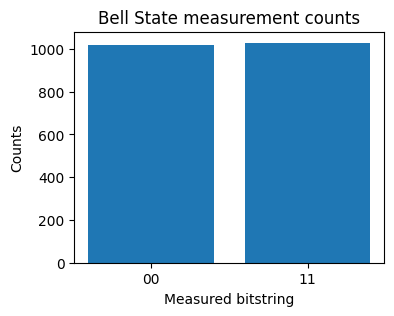

In [ ]:
import matplotlib.pyplot as plt

keys = sorted(bell_counts.keys())

values = [bell_counts[k] for k in keys]

plt.figure(figsize=(4, 3))
plt.bar(keys, values)
plt.title("Bell State measurement counts")
plt.xlabel("Measured bitstring")
plt.ylabel("Counts")
plt.show()
